### Cell 1: Import thư viện và Tải tài nguyên NLTK

In [1]:
import os
import re
import string
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC

from wordcloud import WordCloud

from IPython.display import display

# Cấu hình đồ họa
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Tắt cảnh báo không cần thiết để báo cáo sạch hơn
warnings.filterwarnings('ignore')

# Khai báo các hằng số (Constants) dùng chung cho toàn dự án
RANDOM_STATE = 42
MAX_TFIDF_FEATURES = 5000

# Download NLTK data (Chỉ cần chạy 1 lần)
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

### Cell 2: Khởi tạo các hàm Tiền xử lý dữ liệu (Preprocessing)

In [2]:
# Khởi tạo Lemmatizer và Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
political_stopwords = {'said', 'also', 'would', 'could', 'told', 'reuters', 'washington', 'statement', 'press'}
stop_words.update(political_stopwords)

def deep_clean_text(text):
    """Làm sạch thô văn bản văn bản: xóa header Reuters, URL, HTML, dấu câu, kí tự rác"""
    text = str(text)
    # 1. Xử lý Header nguồn tin & địa danh
    text = re.sub(r'^.*?\\(reuters\\)\\s*[-–—]\\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^.*?\\s?[-–—]\\s?', '', text, count=1)
    
    # 2. Chuẩn hóa & Xóa rác web
    text = text.lower()
    text = re.sub(r'https?://\\S+|www\\.\\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    
    # 3. Xóa dấu câu & khoảng trắng thừa
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\\n', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

def lemmatize_and_remove_stopwords(text):
    """Chuẩn hóa ngôn ngữ bằng cách tách từ, xóa stopwords và Lemmatization"""
    words = str(text).split()
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(clean_words)

### Cell 3: Đọc, Làm sạch, Chuẩn hóa Dữ liệu, Phân tách Tập dữ liệu

In [3]:
# 1. Đọc dữ liệu thô
df_fake = pd.read_csv('../data/raw/Fake.csv')
df_true = pd.read_csv('../data/raw/True.csv')

def explore_raw_data(df, dataset_name):
    print("=" * 60)
    print(f"📊 THỐNG KÊ DỮ LIỆU THÔ: {dataset_name}")
    print("=" * 60)
    
    # 2.1. Kích thước
    print(f"1. Kích thước tập dữ liệu:")
    print(f"   - Số dòng (Bài báo): {df.shape[0]:,}")
    print(f"   - Số cột (Đặc trưng): {df.shape[1]}")
    
    # 2.2. Kiểm tra Null/Missing values
    print(f"\n2. Số lượng giá trị thiếu (Missing Values):")
    missing_data = df.isnull().sum()
    if missing_data.sum() == 0:
        print("   -> Tuyệt vời! Không có giá trị nào bị thiếu.")
    else:
        print(missing_data[missing_data > 0])
        
    # 2.3. Kiểm tra Trùng lặp (Duplicates)
    # Lưu ý: Ở đây ta soi trùng lặp trên toàn bộ các cột
    duplicates = df.duplicated().sum()
    print(f"\n3. Số lượng dòng trùng lặp (Duplicates):")
    print(f"   -> Phát hiện {duplicates:,} dòng bị trùng lặp hoàn toàn.")
    
    # 2.4. Xem nhanh các cột
    print(f"\n4. Danh sách các cột và kiểu dữ liệu:")
    for col in df.columns:
        print(f"   - {col:<10} : {df[col].dtype}")
    
    print("\n")

def explore_processed_data(df, train_idx, test_idx):
    print("\n" + "=" * 60)
    print("📊 THỐNG KÊ DỮ LIỆU SAU TIỀN XỬ LÝ (CLEANED DATA)")
    print("=" * 60)
    
    # 1. Kích thước mới
    print(f"1. Kích thước tập dữ liệu cuối cùng:")
    print(f"   - Số dòng: {df.shape[0]:,} (Đã xóa các dòng lỗi, rỗng và trùng lặp)")
    print(f"   - Số cột: {df.shape[1]}")
    
    # 2. Phân bổ nhãn
    true_cnt = len(df[df['label'] == 0])
    fake_cnt = len(df[df['label'] == 1])
    print(f"\n2. Phân bổ nhãn (Class Distribution):")
    print(f"   - Tin thật (0): {true_cnt:,} ({true_cnt/len(df)*100:.2f}%)")
    print(f"   - Tin giả (1) : {fake_cnt:,} ({fake_cnt/len(df)*100:.2f}%)")
    
    # 3. Kích thước Train/Test
    print(f"\n3. Phân bổ Tập huấn luyện và Kiểm thử (Train/Test Split):")
    print(f"   - Tập Train: {len(train_idx):,} mẫu ({len(train_idx)/len(df)*100:.1f}%)")
    print(f"   - Tập Test : {len(test_idx):,} mẫu ({len(test_idx)/len(df)*100:.1f}%)")
    
    # 4. Xác nhận độ sạch
    print(f"\n4. Kiểm tra chất lượng dữ liệu cuối:")
    missing = df.isnull().sum().sum()
    dups = df.duplicated(subset=['text_only_clean']).sum()
    print(f"   - Số lượng giá trị thiếu (Null/NaN): {missing} -> {'ĐẠT' if missing == 0 else 'CẢNH BÁO'}")
    print(f"   - Số lượng dòng trùng lặp sâu: {dups} -> {'ĐẠT' if dups == 0 else 'CẢNH BÁO'}")
    
    # 5. Cấu trúc cột sau khi làm sạch
    print(f"\n5. Danh sách các cột đã được giữ lại và tạo mới:")
    for col in df.columns:
        print(f"   - {col}")
    print("=" * 60 + "\n")

# 3. Chạy thống kê cho cả 2 tập
explore_raw_data(df_fake, "TẬP TIN GIẢ (FAKE.CSV)")
explore_raw_data(df_true, "TẬP TIN THẬT (TRUE.CSV)")

# 2. Gán nhãn và Gộp bài báo
df_fake['label'] = 1
df_true['label'] = 0

print("Đang tiền xử lý và chia thời gian phân tầng...")

# 1. Ép kiểu thời gian
df_fake['date_parsed'] = pd.to_datetime(df_fake['date'], errors='coerce')
df_true['date_parsed'] = pd.to_datetime(df_true['date'], errors='coerce')

# 2. Xóa các dòng lỗi thời gian và Sắp xếp riêng từng tập
df_fake = df_fake.dropna(subset=['date_parsed']).sort_values('date_parsed').reset_index(drop=True)
df_true = df_true.dropna(subset=['date_parsed']).sort_values('date_parsed').reset_index(drop=True)

# 3. Đánh dấu cờ 'is_test' (80% quá khứ là False, 20% tương lai là True)
df_fake['is_test'] = False
df_fake.loc[int(len(df_fake) * 0.8):, 'is_test'] = True

df_true['is_test'] = False
df_true.loc[int(len(df_true) * 0.8):, 'is_test'] = True

# 4. Gộp chung lại thành 1 DataFrame duy nhất
df = pd.concat([df_fake, df_true], axis=0).reset_index(drop=True)

# 5. Loại bỏ hàng trùng lặp/thiếu trên văn bản gốc
df = df.drop_duplicates(subset=['text']).dropna(subset=['text']).reset_index(drop=True)
df = df[df['text'].str.strip() != ""].reset_index(drop=True)

# 6. Làm sạch sâu văn bản thô
df['text_clean_raw'] = df['text'].apply(deep_clean_text)
df['title_clean_raw'] = df['title'].apply(deep_clean_text)

# 7. Tạo 2 phiên bản dữ liệu nền tảng chưa Lemmatize (để đếm ký tự hoa/dấu câu chính xác)
df['text_only_base'] = df['text_clean_raw']
df['title_text_base'] = df['title_clean_raw'] + " " + df['text_clean_raw']
df['title_only_base'] = df['title_clean_raw']

# 8. Thực hiện Lemmatization cho bước Vector hóa
df['text_only_clean'] = df['text_only_base'].apply(lemmatize_and_remove_stopwords)
df['title_text_clean'] = df['title_text_base'].apply(lemmatize_and_remove_stopwords)
df['title_only_clean'] = df['title_only_base'].apply(lemmatize_and_remove_stopwords)

# Xóa trùng lặp sâu
df = df.drop_duplicates(subset=['text_only_clean']).reset_index(drop=True) # type: ignore
df = df[df['text_only_clean'].str.strip() != ""].reset_index(drop=True)

train_idx = df[df['is_test'] == False].index
test_idx = df[df['is_test'] == True].index

y_train = df.loc[train_idx, 'label']
y_test = df.loc[test_idx, 'label']

# Xóa các cột tạm để không gây rò rỉ dữ liệu
df.drop(columns=['subject', 'date', 'date_parsed', 'is_test'], inplace=True, errors='ignore')

explore_processed_data(df, train_idx, test_idx)

print(f"-> Tập Train: {len(train_idx)} mẫu | Tập Test: {len(test_idx)} mẫu")
print(f"-> Số tin Thật trong Test: {len(y_test[y_test == 0])} | Số tin Giả trong Test: {len(y_test[y_test == 1])}")

# 7. Lưu file đã xử lý
output_path = '../data/processed/processed_data.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Đã xử lý xong dữ liệu và lưu tại: {output_path}")

📊 THỐNG KÊ DỮ LIỆU THÔ: TẬP TIN GIẢ (FAKE.CSV)
1. Kích thước tập dữ liệu:
   - Số dòng (Bài báo): 23,481
   - Số cột (Đặc trưng): 4

2. Số lượng giá trị thiếu (Missing Values):
   -> Tuyệt vời! Không có giá trị nào bị thiếu.

3. Số lượng dòng trùng lặp (Duplicates):
   -> Phát hiện 3 dòng bị trùng lặp hoàn toàn.

4. Danh sách các cột và kiểu dữ liệu:
   - title      : str
   - text       : str
   - subject    : str
   - date       : str


📊 THỐNG KÊ DỮ LIỆU THÔ: TẬP TIN THẬT (TRUE.CSV)
1. Kích thước tập dữ liệu:
   - Số dòng (Bài báo): 21,417
   - Số cột (Đặc trưng): 4

2. Số lượng giá trị thiếu (Missing Values):
   -> Tuyệt vời! Không có giá trị nào bị thiếu.

3. Số lượng dòng trùng lặp (Duplicates):
   -> Phát hiện 206 dòng bị trùng lặp hoàn toàn.

4. Danh sách các cột và kiểu dữ liệu:
   - title      : str
   - text       : str
   - subject    : str
   - date       : str


Đang tiền xử lý và chia thời gian phân tầng...

📊 THỐNG KÊ DỮ LIỆU SAU TIỀN XỬ LÝ (CLEANED DATA)
1. Kích thước 

In [4]:
import hashlib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("="*70)
print(" KIỂM TRA DATA LEAKAGE NÂNG CAO (HASH & SIMILARITY)".center(70))
print("="*70)

# Lấy dữ liệu văn bản đã làm sạch
train_texts = df.loc[train_idx, 'text_only_clean'].values
test_texts = df.loc[test_idx, 'text_only_clean'].values

# ---------------------------------------------------------
# KỸ THUẬT 1: HASHING (BẮT TRÙNG LẶP CHÍNH XÁC 100%)
# ---------------------------------------------------------
print("\n1. Đang kiểm tra bằng mã băm (MD5 Hash)...")
def get_md5_hash(text):
    """Biến đổi văn bản thành chuỗi mã băm 32 ký tự để so sánh siêu nhanh"""
    return hashlib.md5(str(text).encode('utf-8')).hexdigest()

train_hashes = set([get_md5_hash(text) for text in train_texts])
test_hashes = set([get_md5_hash(text) for text in test_texts])

hash_overlap = train_hashes.intersection(test_hashes)
print(f" -> Số bài báo trùng lặp hoàn toàn (Hash Overlap): {len(hash_overlap)}")


# ---------------------------------------------------------
# KỸ THUẬT 2: COSINE SIMILARITY (BẮT GẦN TRÙNG - NEAR DUPLICATES)
# ---------------------------------------------------------
print("\n2. Đang kiểm tra bài viết 'gần trùng' (Cosine Similarity)...")
# Giới hạn 5000 features để tránh tràn RAM khi tính ma trận
sim_vec = TfidfVectorizer(max_features=5000) 
train_matrix = sim_vec.fit_transform(train_texts)
test_matrix = sim_vec.transform(test_texts)

# Tính độ tương đồng giữa tập Test và tập Train
# Kết quả trả về ma trận (len(test), len(train))
similarity_matrix = cosine_similarity(test_matrix, train_matrix)

# Đặt ngưỡng 90% (0.9): Nếu giống nhau trên 90% thì coi như là sao chép/leakage
THRESHOLD = 0.90
near_duplicates = np.where(similarity_matrix > THRESHOLD)

test_dup_indices = near_duplicates[0]
train_dup_indices = near_duplicates[1]

# Lọc bỏ các cặp trùng lặp 100% (đã bị bắt bởi Hash) để tìm ra số lượng thực sự "gần trùng"
# similarity_matrix có giá trị xấp xỉ 1.0 cho các bài trùng hoàn toàn
near_but_not_exact = np.where((similarity_matrix > THRESHOLD) & (similarity_matrix < 0.99))
print(f" -> Số cặp bài báo 'gần trùng' (Giống nhau 90% - 99%): {len(near_but_not_exact[0])}")

print("\n" + "="*70)

          KIỂM TRA DATA LEAKAGE NÂNG CAO (HASH & SIMILARITY)          

1. Đang kiểm tra bằng mã băm (MD5 Hash)...
 -> Số bài báo trùng lặp hoàn toàn (Hash Overlap): 0

2. Đang kiểm tra bài viết 'gần trùng' (Cosine Similarity)...
 -> Số cặp bài báo 'gần trùng' (Giống nhau 90% - 99%): 12



### Cell 4: Phân tích Khám phá Dữ liệu (EDA)

=== THỐNG KÊ MẪU DỮ LIỆU ===
Tổng số mẫu: 31777 | Số đặc trưng: 11
Tin thật (0): 21188 (66.68%) | Tin giả (1): 10589 (33.32%)


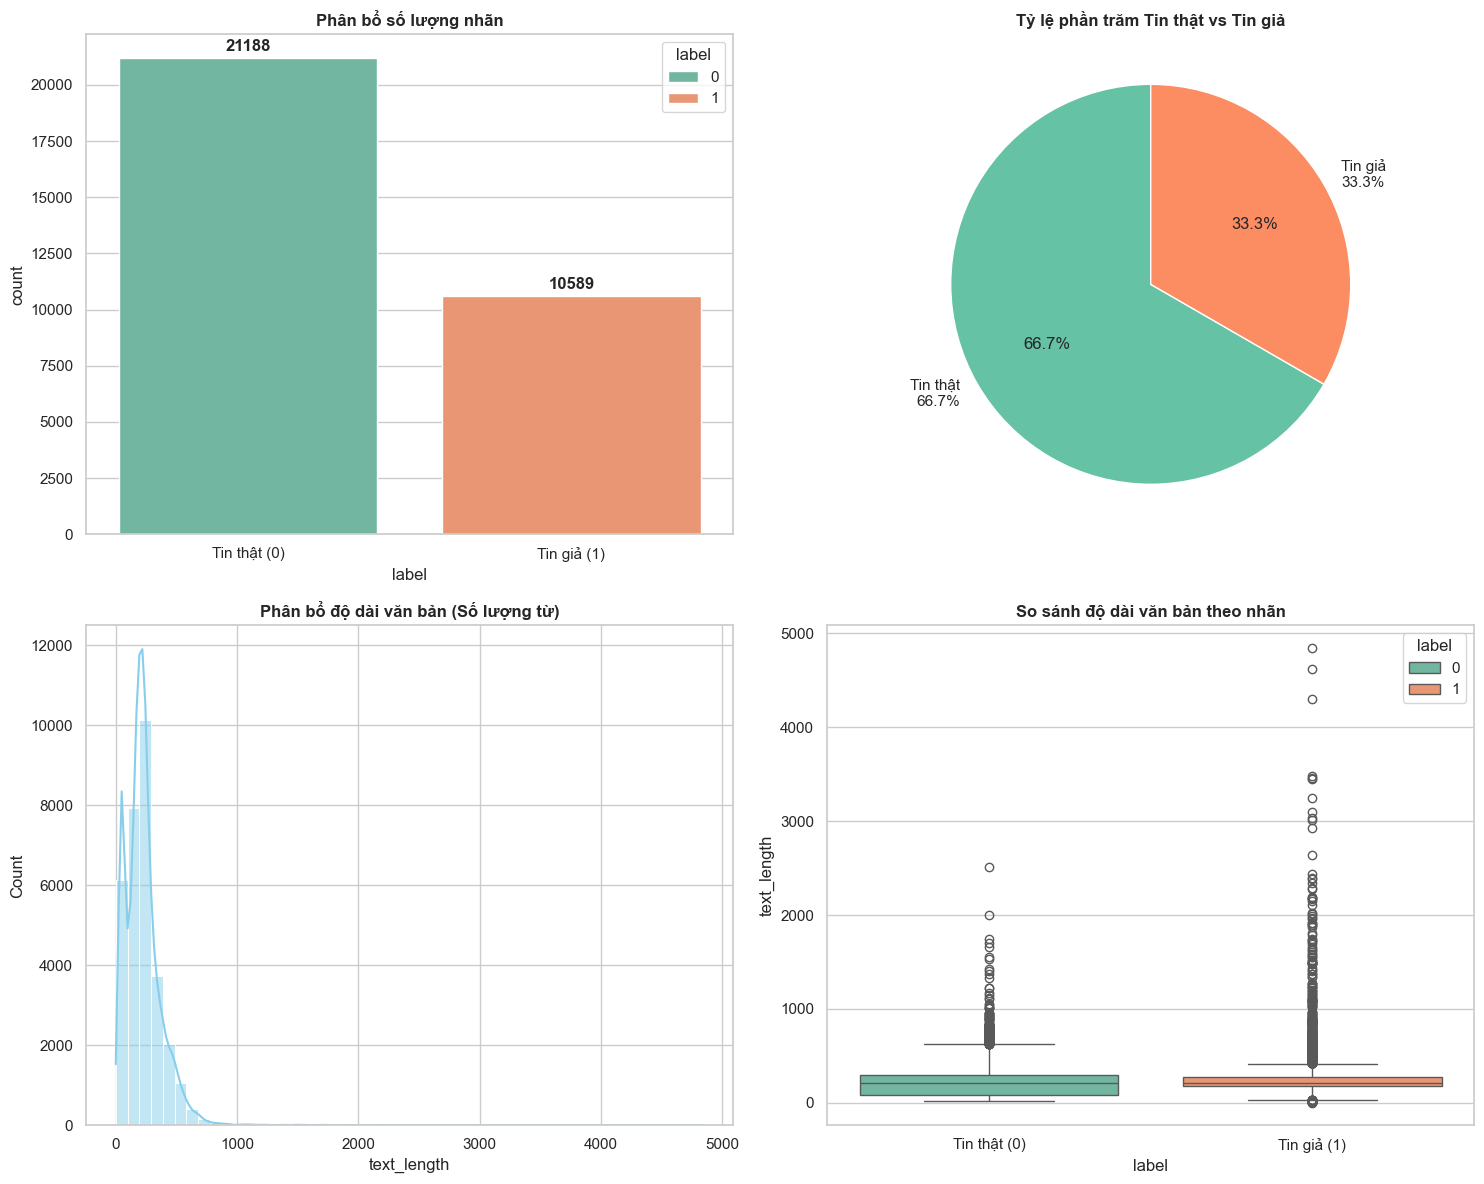

In [5]:
num_samples, num_features = df.shape

# [SỬA LỖI KEYERROR Ở ĐÂY]: Đếm trực tiếp từ DataFrame, an toàn tuyệt đối
true_count = len(df[df['label'] == 0])
fake_count = len(df[df['label'] == 1])

print(f"=== THỐNG KÊ MẪU DỮ LIỆU ===\nTổng số mẫu: {num_samples} | Số đặc trưng: {num_features}")
print(f"Tin thật (0): {true_count} ({true_count/num_samples*100:.2f}%) | Tin giả (1): {fake_count} ({fake_count/num_samples*100:.2f}%)")

# Tạo trường độ dài văn bản để trực quan hóa
df['text_length'] = df['text_only_clean'].apply(lambda x: len(str(x).split()))

# Vẽ đồ thị 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Subplot 1: Countplot
# THÊM order=[0, 1] để khóa cứng cột 0 nằm trái, cột 1 nằm phải
sns.countplot(x='label', hue='label', data=df, palette='Set2', ax=axes[0, 0], order=[0, 1])
axes[0, 0].set_title('Phân bổ số lượng nhãn', fontweight='bold')
axes[0, 0].set_xticklabels(['Tin thật (0)', 'Tin giả (1)'])

# Ghi số lượng lên đỉnh cột
for i, v in enumerate([true_count, fake_count]):
    axes[0, 0].text(i, v + (num_samples * 0.01), str(v), ha='center', fontweight='bold')

# Subplot 2: Pie chart
axes[0, 1].pie([true_count, fake_count], 
               labels=[f'Tin thật\n{true_count/num_samples*100:.1f}%', f'Tin giả\n{fake_count/num_samples*100:.1f}%'], 
               colors=['#66c2a5', '#fc8d62'], autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Tỷ lệ phần trăm Tin thật vs Tin giả', fontweight='bold')

# Subplot 3: Phân bổ độ dài từ
sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue', ax=axes[1, 0])
axes[1, 0].set_title('Phân bổ độ dài văn bản (Số lượng từ)', fontweight='bold')

# Subplot 4: Boxplot độ dài theo nhãn
# THÊM order=[0, 1] để đồng bộ màu sắc và vị trí với các biểu đồ khác
sns.boxplot(x='label', y='text_length', hue='label', data=df, palette='Set2', ax=axes[1, 1], order=[0, 1])
axes[1, 1].set_title('So sánh độ dài văn bản theo nhãn', fontweight='bold')
axes[1, 1].set_xticklabels(['Tin thật (0)', 'Tin giả (1)'])

plt.tight_layout()
plt.show()

### Cell 5: Phân tách Tập dữ liệu & Kỹ nghệ Đặc trưng (Feature Engineering Pipeline)

In [6]:
print("Đang kiểm tra rò rỉ dữ liệu (trùng lặp) giữa tập Train và Test...")

# Lấy tập hợp các văn bản đã làm sạch ở kịch bản Text Only
train_texts_set = set(df.loc[train_idx, 'text_only_clean'])
test_texts_set = set(df.loc[test_idx, 'text_only_clean'])

# Tìm phần giao nhau (trùng lặp)
exact_overlap = train_texts_set.intersection(test_texts_set)

print(f"-> Số lượng bài báo trùng lặp hoàn toàn giữa Train và Test: {len(exact_overlap)}")
if len(exact_overlap) == 0:
    print("-> Tuyệt vời! Không có hiện tượng học vẹt do trùng lặp dữ liệu.")
else:
    print("-> CẢNH BÁO: Cần xem lại bước df.drop_duplicates() ở phần làm sạch dữ liệu!")
print("="*69 + "\n")

def extract_meta_features(text_series):
    """Tính toán các đặc trưng thủ công (Độ dài bài viết, Tỷ lệ viết hoa, Tỷ lệ dấu câu)"""
    def count_punct(text):
        words = str(text).split()
        if not words: return 0
        punct_count = sum(1 for char in text if char in string.punctuation)
        return (punct_count / len(words)) * 100

    def count_caps(text):
        words = str(text).split()
        if not words: return 0
        cap_count = sum(1 for char in text if char.isupper())
        return (cap_count / len(words)) * 100

    lengths = text_series.apply(lambda x: len(str(x).split())).values.reshape(-1, 1)
    puncts = text_series.apply(count_punct).values.reshape(-1, 1)
    caps = text_series.apply(count_caps).values.reshape(-1, 1)
    
    return np.hstack([lengths, puncts, caps])

def build_feature_pipeline(clean_col, base_col):
    """Pipeline xây dựng ma trận đặc trưng kết hợp TF-IDF và Meta Features hoàn chỉnh"""
    # 1. Trích xuất văn bản tương ứng
    X_train_clean = df.loc[train_idx, clean_col]
    X_test_clean = df.loc[test_idx, clean_col]
    X_train_base = df.loc[train_idx, base_col]
    X_test_base = df.loc[test_idx, base_col]
    
    # 2. Vector hóa TF-IDF bằng dữ liệu đã chuẩn hóa (clean)
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=MAX_TFIDF_FEATURES, stop_words='english')
    X_train_tfidf = tfidf.fit_transform(X_train_clean).toarray()
    X_test_tfidf = tfidf.transform(X_test_clean).toarray()
    
    # 3. Tính toán Meta Features từ dữ liệu nền tảng gốc (base) để không mất thông tin hoa/dấu câu
    train_meta = extract_meta_features(X_train_base)
    test_meta = extract_meta_features(X_test_base)
    
    # 4. Ghép mảng đặc trưng
    X_train_full = np.hstack([X_train_tfidf, train_meta])
    X_test_full = np.hstack([X_test_tfidf, test_meta])
    
    # 5. Chuẩn hóa tỷ lệ (MinMax Scaling)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled = scaler.transform(X_test_full)
    
    return X_train_scaled, X_test_scaled, tfidf

# Tiến hành tạo tập dữ liệu cho 2 kịch bản thử nghiệm
print("Đang trích xuất đặc trưng cho kịch bản 'Text Only'...")
X_train_text, X_test_text, tfidf_text = build_feature_pipeline('text_only_clean', 'text_only_base')

print("Đang trích xuất đặc trưng cho kịch bản 'Title + Text'...")
X_train_title, X_test_title, tfidf_title = build_feature_pipeline('title_text_clean', 'title_text_base')

print("Đang trích xuất đặc trưng cho kịch bản 'Title Only'...")
X_train_title_only, X_test_title_only, tfidf_title_only = build_feature_pipeline('title_only_clean', 'title_only_base')

Đang kiểm tra rò rỉ dữ liệu (trùng lặp) giữa tập Train và Test...
-> Số lượng bài báo trùng lặp hoàn toàn giữa Train và Test: 0
-> Tuyệt vời! Không có hiện tượng học vẹt do trùng lặp dữ liệu.

Đang trích xuất đặc trưng cho kịch bản 'Text Only'...
Đang trích xuất đặc trưng cho kịch bản 'Title + Text'...
Đang trích xuất đặc trưng cho kịch bản 'Title Only'...


### Cell 6: Hàm Huấn luyện và Đánh giá Mô hình đa dụng

In [7]:
def train_and_evaluate_model(model, model_name, X_train, X_test, cmap="Blues"):
    """Hàm huấn luyện mô hình chung giúp tối giản hóa mã nguồn"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Vẽ Confusion Matrix trực quan
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Dự đoán 0', 'Dự đoán 1'],
                yticklabels=['Thực tế 0', 'Thực tế 1'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()
    
    return acc, report

def display_comparison_report(model_name, acc_title_text, report_title_text, acc_text_only, report_text_only, acc_title_only, report_title_only):
    """In bảng so sánh chi tiết kết quả chạy thực nghiệm cho 3 kịch bản"""
    print("=" * 95)
    print(f"{f'SO SÁNH MÔ HÌNH: {model_name}':^95}")
    print("=" * 95)
    
    # Cập nhật thêm cột Title Only
    print(f"{'Chỉ số (Metric)':<25} {'Title + Text':>20} {'Text Only':>20} {'Title Only':>20}")
    print("-" * 95)
    
    for cls, name in [('0', 'Tin thật'), ('1', 'Tin giả')]:
        print(f"{f'{name} Precision':<25} {report_title_text[cls]['precision']:>20.3f} {report_text_only[cls]['precision']:>20.3f} {report_title_only[cls]['precision']:>20.3f}")
        print(f"{f'{name} Recall':<25} {report_title_text[cls]['recall']:>20.3f} {report_text_only[cls]['recall']:>20.3f} {report_title_only[cls]['recall']:>20.3f}")
        print(f"{f'{name} F1-score':<25} {report_title_text[cls]['f1-score']:>20.3f} {report_text_only[cls]['f1-score']:>20.3f} {report_title_only[cls]['f1-score']:>20.3f}")
        print("-" * 95)
        
    print(f"{'Độ chính xác (Accuracy)':<25} {acc_title_text:>20.3f} {acc_text_only:>20.3f} {acc_title_only:>20.3f}\n")

### Cell 7: Thực nghiệm 1 - Logistic Regression

--- HUẤN LUYỆN LOGISTIC REGRESSION ---


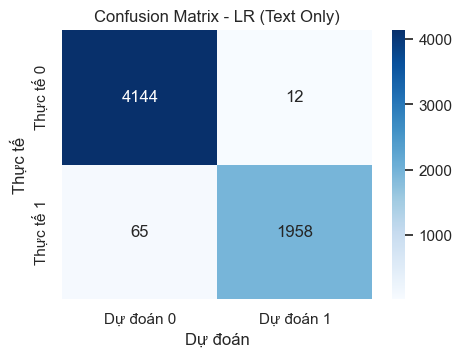

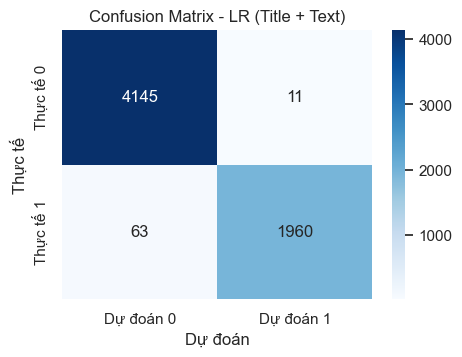

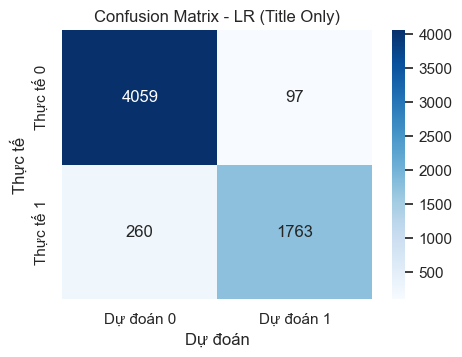

                             SO SÁNH MÔ HÌNH: LOGISTIC REGRESSION                              
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.985                0.985                0.940
Tin thật Recall                          0.997                0.997                0.977
Tin thật F1-score                        0.991                0.991                0.958
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.994                0.994                0.948
Tin giả Recall                           0.969                0.968                0.871
Tin giả F1-score                         0.981                0.981                0.908
-----------------------------------------------------------------------------------------

In [8]:
print("--- HUẤN LUYỆN LOGISTIC REGRESSION ---")
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')

acc_lr_text, rep_lr_text = train_and_evaluate_model(lr_model, "LR (Text Only)", X_train_text, X_test_text, "Blues")
acc_lr_title, rep_lr_title = train_and_evaluate_model(lr_model, "LR (Title + Text)", X_train_title, X_test_title, "Blues")
acc_lr_title_only, rep_lr_title_only = train_and_evaluate_model(lr_model, "LR (Title Only)", X_train_title_only, X_test_title_only, "Blues")

display_comparison_report("LOGISTIC REGRESSION", acc_lr_title, rep_lr_title, acc_lr_text, rep_lr_text, acc_lr_title_only, rep_lr_title_only)

### Cell 8: Thực nghiệm 2 - Naive Bayes

--- HUẤN LUYỆN NAIVE BAYES ---


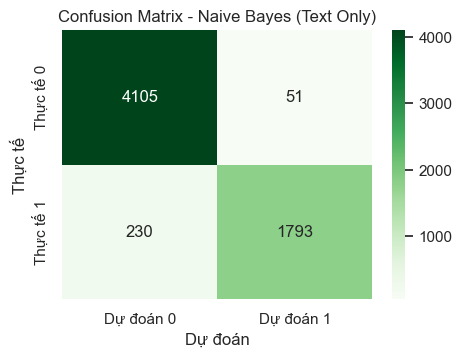

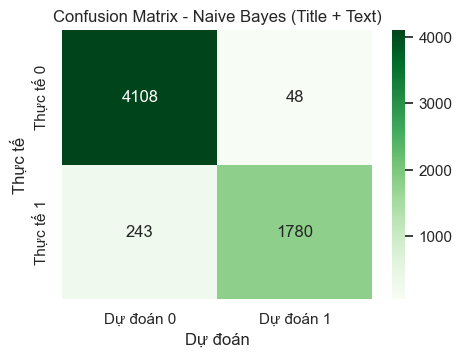

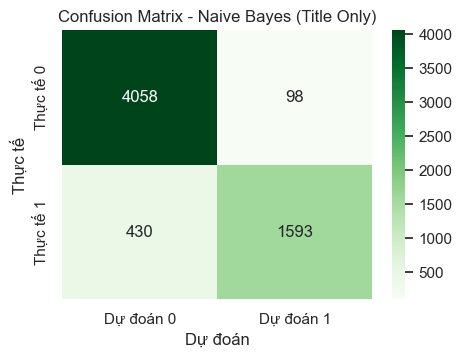

                                 SO SÁNH MÔ HÌNH: NAIVE BAYES                                  
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.944                0.947                0.904
Tin thật Recall                          0.988                0.988                0.976
Tin thật F1-score                        0.966                0.967                0.939
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.974                0.972                0.942
Tin giả Recall                           0.880                0.886                0.787
Tin giả F1-score                         0.924                0.927                0.858
-----------------------------------------------------------------------------------------

In [9]:
print("--- HUẤN LUYỆN NAIVE BAYES ---")
nb_model = MultinomialNB()

acc_nb_text, rep_nb_text = train_and_evaluate_model(nb_model, "Naive Bayes (Text Only)", X_train_text, X_test_text, "Greens")
acc_nb_title, rep_nb_title = train_and_evaluate_model(nb_model, "Naive Bayes (Title + Text)", X_train_title, X_test_title, "Greens")
acc_nb_title_only, rep_nb_title_only = train_and_evaluate_model(nb_model, "Naive Bayes (Title Only)", X_train_title_only, X_test_title_only, "Greens")

display_comparison_report("NAIVE BAYES", acc_nb_title, rep_nb_title, acc_nb_text, rep_nb_text, acc_nb_title_only, rep_nb_title_only)

### Cell 9: Thực nghiệm 3 - SVM (Linear Support Vector Classifier)

--- HUẤN LUYỆN SVM ---


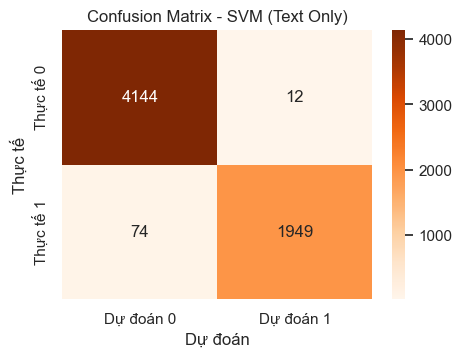

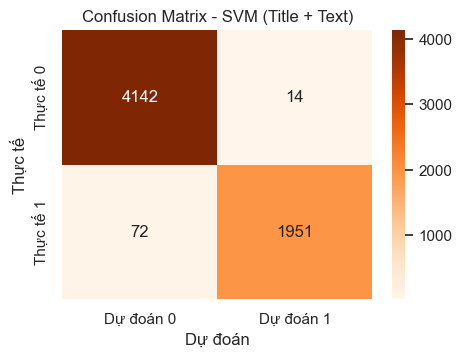

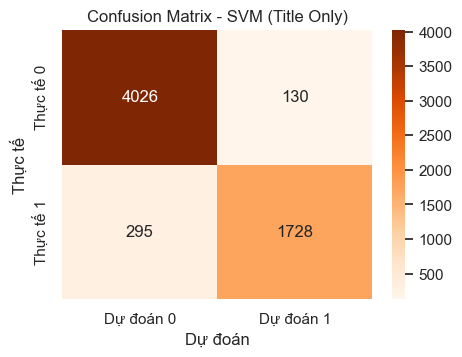

                                     SO SÁNH MÔ HÌNH: SVM                                      
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.983                0.982                0.932
Tin thật Recall                          0.997                0.997                0.969
Tin thật F1-score                        0.990                0.990                0.950
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.993                0.994                0.930
Tin giả Recall                           0.964                0.963                0.854
Tin giả F1-score                         0.978                0.978                0.890
-----------------------------------------------------------------------------------------

In [10]:
print("--- HUẤN LUYỆN SVM ---")
svm_model = LinearSVC(random_state=RANDOM_STATE, max_iter=2000, class_weight='balanced')

acc_svm_text, rep_svm_text = train_and_evaluate_model(svm_model, "SVM (Text Only)", X_train_text, X_test_text, "Oranges")
acc_svm_title, rep_svm_title = train_and_evaluate_model(svm_model, "SVM (Title + Text)", X_train_title, X_test_title, "Oranges")
acc_svm_title_only, rep_svm_title_only = train_and_evaluate_model(svm_model, "SVM (Title Only)", X_train_title_only, X_test_title_only, "Oranges")

display_comparison_report("SVM", acc_svm_title, rep_svm_title, acc_svm_text, rep_svm_text, acc_svm_title_only, rep_svm_title_only)

### Cell 10: Phân tích top features

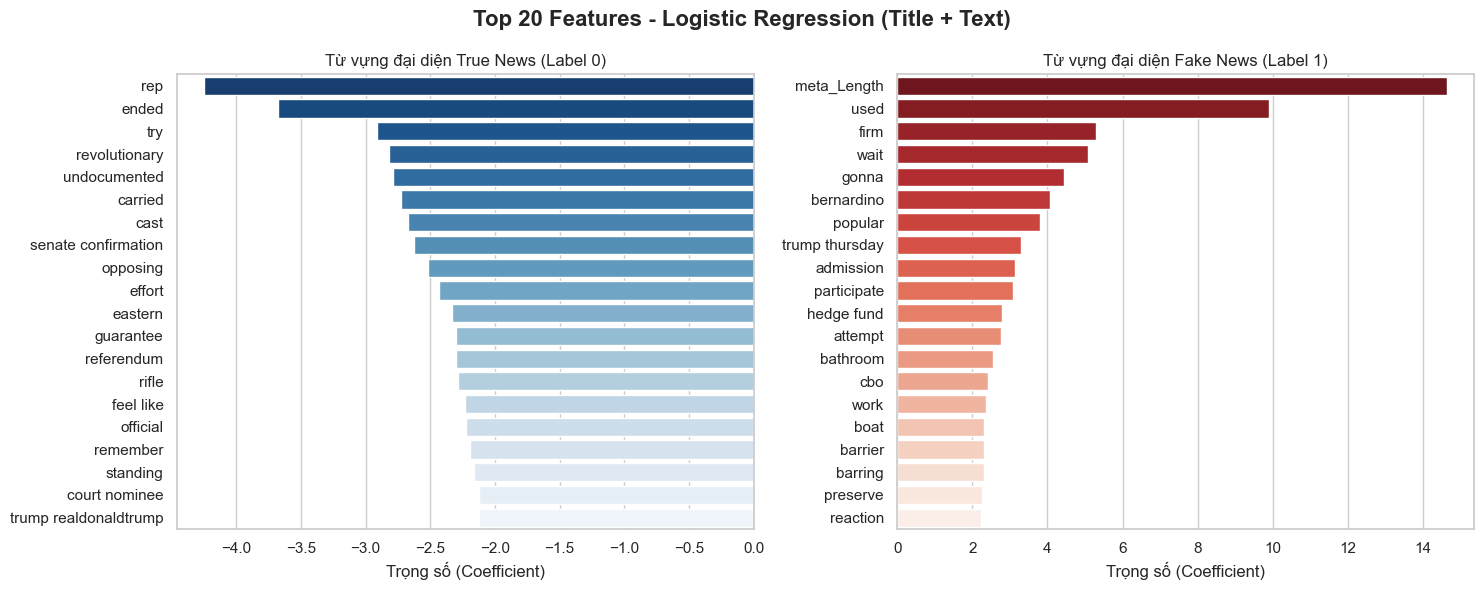

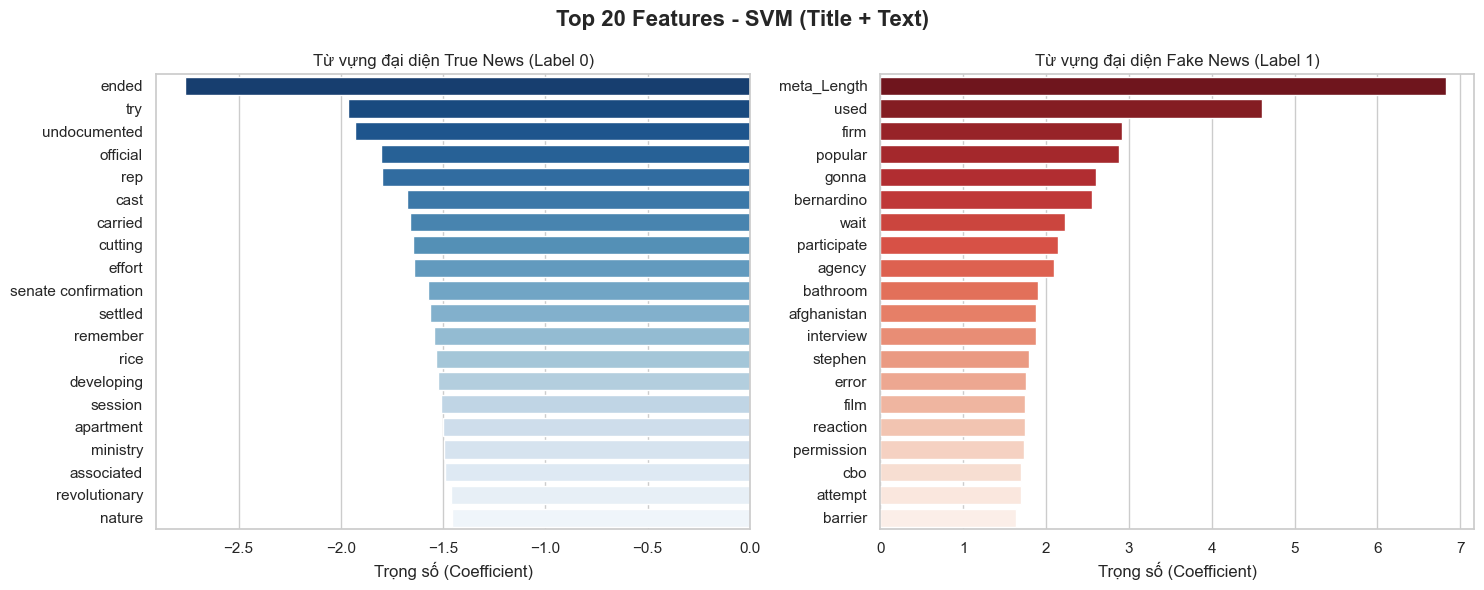

In [11]:
def plot_top_features(vectorizer, model, model_name, top_n=20):
    """
    Hàm vẽ biểu đồ Top Features có hỗ trợ Meta Features
    """
    # 1. Lấy danh sách từ vựng từ TF-IDF
    feature_names = list(vectorizer.get_feature_names_out())
    
    # 2. Thêm thủ công 3 tên Meta Features cho khớp với ma trận np.hstack của bạn
    feature_names.extend(['meta_Length', 'meta_Punctuation', 'meta_Capitals'])
    
    # 3. Lấy trọng số của mô hình
    coefs = model.coef_[0]
    
    # 4. Kiểm tra an toàn độ dài
    if len(feature_names) != len(coefs):
        print(f"Lỗi: Số lượng features ({len(feature_names)}) không khớp với số lượng weights ({len(coefs)}).")
        return
        
    # 5. Ghép từ vựng và trọng số
    features_with_coefs = list(zip(feature_names, coefs))
    
    # 6. Sắp xếp
    top_true_features = sorted(features_with_coefs, key=lambda x: x[1])[:top_n]
    top_fake_features = sorted(features_with_coefs, key=lambda x: x[1], reverse=True)[:top_n]
    
    # Tách dữ liệu để vẽ
    true_words, true_scores = zip(*top_true_features)
    fake_words, fake_scores = zip(*top_fake_features)
    
    # Trực quan hóa
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Top {top_n} Features - {model_name}', fontsize=16, fontweight='bold')
    
    sns.barplot(x=list(true_scores), y=list(true_words), ax=axes[0], palette='Blues_r')
    axes[0].set_title('Từ vựng đại diện True News (Label 0)')
    axes[0].set_xlabel('Trọng số (Coefficient)')
    
    sns.barplot(x=list(fake_scores), y=list(fake_words), ax=axes[1], palette='Reds_r')
    axes[1].set_title('Từ vựng đại diện Fake News (Label 1)')
    axes[1].set_xlabel('Trọng số (Coefficient)')
    
    plt.tight_layout()
    plt.show()

# Đảm bảo bạn gọi đoạn này SAU KHI đã huấn luyện xong lr_model và svm_model
plot_top_features(tfidf_title, lr_model, "Logistic Regression (Title + Text)")
plot_top_features(tfidf_title, svm_model, "SVM (Title + Text)")

### Cell 11: Tổng hợp kết quả toàn bộ thử nghiệm

In [12]:
import pandas as pd

def extract_macro_metrics(acc, report):
    """
    Hàm phụ trợ trích xuất chỉ số trung bình (macro avg) từ classification_report
    """
    return {
        "Accuracy": f"{acc:.4f}",
        "Precision": f"{report['macro avg']['precision']:.4f}",
        "Recall": f"{report['macro avg']['recall']:.4f}",
        "F1-score": f"{report['macro avg']['f1-score']:.4f}"
    }

# Lấy dữ liệu cho từng cấu hình
data = []

# --- 1. LOGISTIC REGRESSION ---
lr_text = extract_macro_metrics(acc_lr_text, rep_lr_text)
data.append(["Logistic Regression", "Text Only", lr_text['Accuracy'], lr_text['Precision'], lr_text['Recall'], lr_text['F1-score']])

lr_title_text = extract_macro_metrics(acc_lr_title, rep_lr_title)
data.append(["Logistic Regression", "Title + Text", lr_title_text['Accuracy'], lr_title_text['Precision'], lr_title_text['Recall'], lr_title_text['F1-score']])

lr_title_only = extract_macro_metrics(acc_lr_title_only, rep_lr_title_only)
data.append(["Logistic Regression", "Title Only", lr_title_only['Accuracy'], lr_title_only['Precision'], lr_title_only['Recall'], lr_title_only['F1-score']])


# --- 2. NAIVE BAYES ---
# (Đảm bảo bạn đã huấn luyện và lưu các biến acc_nb_..., rep_nb_... tương tự như LR và SVM)
nb_text = extract_macro_metrics(acc_nb_text, rep_nb_text)
data.append(["Naive Bayes", "Text Only", nb_text['Accuracy'], nb_text['Precision'], nb_text['Recall'], nb_text['F1-score']])

nb_title_text = extract_macro_metrics(acc_nb_title, rep_nb_title)
data.append(["Naive Bayes", "Title + Text", nb_title_text['Accuracy'], nb_title_text['Precision'], nb_title_text['Recall'], nb_title_text['F1-score']])

# Nếu bạn chưa làm kịch bản Title Only cho Naive Bayes, hãy huấn luyện nó trước khi chạy dòng này
nb_title_only = extract_macro_metrics(acc_nb_title_only, rep_nb_title_only)
data.append(["Naive Bayes", "Title Only", nb_title_only['Accuracy'], nb_title_only['Precision'], nb_title_only['Recall'], nb_title_only['F1-score']])


# --- 3. SVM ---
svm_text = extract_macro_metrics(acc_svm_text, rep_svm_text)
data.append(["SVM", "Text Only", svm_text['Accuracy'], svm_text['Precision'], svm_text['Recall'], svm_text['F1-score']])

svm_title_text = extract_macro_metrics(acc_svm_title, rep_svm_title)
data.append(["SVM", "Title + Text", svm_title_text['Accuracy'], svm_title_text['Precision'], svm_title_text['Recall'], svm_title_text['F1-score']])

svm_title_only = extract_macro_metrics(acc_svm_title_only, rep_svm_title_only)
data.append(["SVM", "Title Only", svm_title_only['Accuracy'], svm_title_only['Precision'], svm_title_only['Recall'], svm_title_only['F1-score']])

# Tạo DataFrame
columns = ["Mô hình", "Dữ liệu", "Accuracy", "Precision", "Recall", "F1-score"]
summary_df = pd.DataFrame(data, columns=columns)

# In bảng ra màn hình
print("=" * 80)
print(f"{'BẢNG TỔNG HỢP METRICS CÁC MÔ HÌNH VÀ KỊCH BẢN DỮ LIỆU':^80}")
print("=" * 80)
print(summary_df.to_string(index=False, justify='center'))

# (Tùy chọn) Lưu ra file CSV để dán vào báo cáo Word cho dễ
summary_df.to_csv('../data/processed/model_metrics_summary.csv', index=False)

             BẢNG TỔNG HỢP METRICS CÁC MÔ HÌNH VÀ KỊCH BẢN DỮ LIỆU              
      Mô hình         Dữ liệu    Accuracy Precision Recall F1-score
Logistic Regression    Text Only  0.9875    0.9892  0.9825  0.9858 
Logistic Regression Title + Text  0.9880    0.9897  0.9831  0.9863 
Logistic Regression   Title Only  0.9422    0.9438  0.9241  0.9330 
        Naive Bayes    Text Only  0.9545    0.9596  0.9370  0.9471 
        Naive Bayes Title + Text  0.9529    0.9589  0.9342  0.9451 
        Naive Bayes   Title Only  0.9145    0.9231  0.8819  0.8984 
                SVM    Text Only  0.9861    0.9882  0.9803  0.9841 
                SVM Title + Text  0.9861    0.9879  0.9805  0.9841 
                SVM   Title Only  0.9312    0.9309  0.9114  0.9202 


### Cell 12: WordCloud

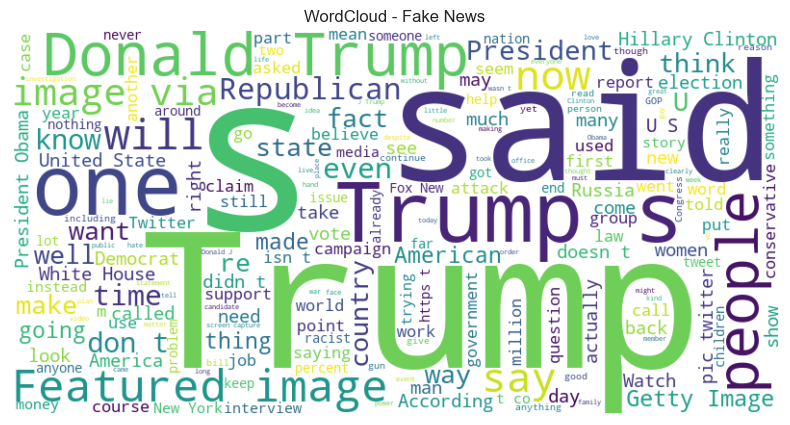

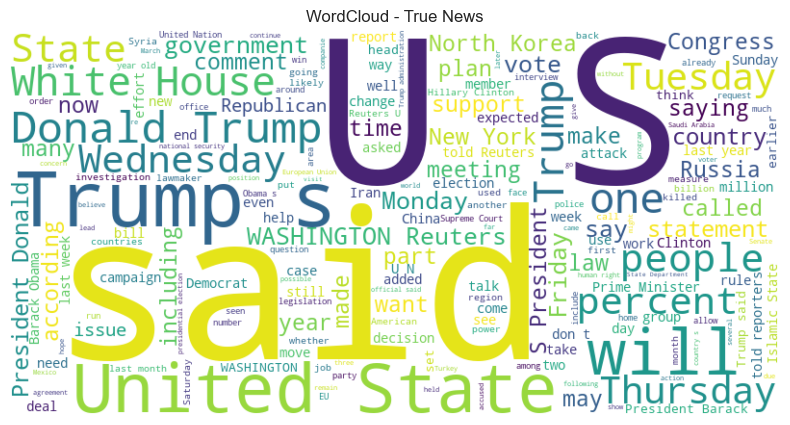

In [13]:
fake_text = " ".join(df[df['label'] == 1]['text'])
true_text = " ".join(df[df['label'] == 0]['text'])

# WordCloud Fake News
wc_fake = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Fake News")
plt.show()

# WordCloud True News
wc_true = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(true_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_true, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - True News")
plt.show()

### Cell 13: Phân tích mẫu dự đoán sai

In [14]:
print("Đang tiến hành trích xuất các mẫu dự đoán sai...")

# 1. Dự đoán lại trên tập Test bằng mô hình tốt nhất (Ví dụ: Logistic Regression với kịch bản Title + Text)
y_pred_analysis = lr_model.predict(X_test_title)

# 2. Tạo DataFrame chứa thông tin để đối chiếu
error_analysis_df = pd.DataFrame({
    'Tiêu đề gốc (Title)': df.loc[test_idx, 'title'],
    'Nội dung gốc (Text)': df.loc[test_idx, 'text'],
    'Thực tế (True Label)': y_test,
    'Dự đoán (Predicted)': y_pred_analysis
})

# 3. Lọc ra các dòng dự đoán sai
errors = error_analysis_df[error_analysis_df['Thực tế (True Label)'] != error_analysis_df['Dự đoán (Predicted)']]

# 4. Tách thành 2 nhóm lỗi
# False Positives (FP): Thực tế là Tin Thật (0) nhưng bị model đoán nhầm là Tin Giả (1)
false_positives = errors[(errors['Thực tế (True Label)'] == 0) & (errors['Dự đoán (Predicted)'] == 1)]

# False Negatives (FN): Thực tế là Tin Giả (1) nhưng bị model đoán nhầm là Tin Thật (0)
false_negatives = errors[(errors['Thực tế (True Label)'] == 1) & (errors['Dự đoán (Predicted)'] == 0)]

print(f"Tổng số mẫu dự đoán sai: {len(errors)}")
print(f" - Số mẫu False Positives (Thật bị đoán là Giả): {len(false_positives)}")
print(f" - Số mẫu False Negatives (Giả bị đoán là Thật): {len(false_negatives)}\n")

# 5. Hiển thị 10 mẫu tiêu biểu cho mỗi loại
print("="*80)
print("📌 TOP 10 FALSE POSITIVES (Thực tế là TIN THẬT, bị đoán nhầm thành TIN GIẢ)")
print("="*80)
# Hiển thị bằng hàm display của IPython để bảng đẹp hơn trong Jupyter
display(false_positives.head(10))

print("\n" + "="*80)
print("📌 TOP 10 FALSE NEGATIVES (Thực tế là TIN GIẢ, bị đoán nhầm thành TIN THẬT)")
print("="*80)
display(false_negatives.head(10))

Đang tiến hành trích xuất các mẫu dự đoán sai...
Tổng số mẫu dự đoán sai: 2046
 - Số mẫu False Positives (Thật bị đoán là Giả): 122
 - Số mẫu False Negatives (Giả bị đoán là Thật): 1924

📌 TOP 10 FALSE POSITIVES (Thực tế là TIN THẬT, bị đoán nhầm thành TIN GIẢ)


,Tiêu đề gốc (Title),Nội dung gốc (Text),Thực tế (True Label),Dự đoán (Predicted)
27657,Russia says didn't promise withdrawal of pro-I...,MOSCOW (Reuters) - Russia has not promised to ...,0,1
27714,Ukraine prosecutor says puzzled by lack of U.S...,KIEV (Reuters) - Ukraine is puzzled by the lac...,0,1
27727,Ukraine's anti-corruption bureau launches case...,KIEV (Reuters) - Ukrainian investigators on Tu...,0,1
27739,Iraqi PM says 'will not wait forever' to take ...,BAGHDAD (Reuters) - Iraqi Prime Minister Haide...,0,1
27755,"Zimbabwe's army seizes power, Mugabe confined ...",HARARE (Reuters) - Zimbabwe s military seized ...,0,1
27785,EU concerned over challenges to Romanian judic...,BUCHAREST (Reuters) - Justice reform has stagn...,0,1
27814,Philippines' Duterte lauds China's help at 'cr...,MANILA (Reuters) - Philippine President Rodrig...,0,1
27816,Factbox: Key figures in Zimbabwe First Lady Gr...,HARARE (Reuters) - Following are key figures i...,0,1
27825,Russia's Lavrov says allegations of meddling i...,MOSCOW (Reuters) - Russian Foreign Minister Se...,0,1
27862,UK's Johnson vows no stone unturned to free ai...,LONDON (Reuters) - Foreign minister Boris John...,0,1



📌 TOP 10 FALSE NEGATIVES (Thực tế là TIN GIẢ, bị đoán nhầm thành TIN THẬT)


,Tiêu đề gốc (Title),Nội dung gốc (Text),Thực tế (True Label),Dự đoán (Predicted)
8566,ELLEN Just Proved She’s A HUGE Hypocrite And K...,Someone needs to educate Ellen DeGeneres on Pr...,1,0
8567,AFTER 5 YEARS Of Being Bullied By Barack Obama...,Freedom is not a gift from government. It is ...,1,0
8568,GOP VETERAN AND DOUBLE AMPUTEE Scorches Democr...,Brian Mast scorched the Democrats for their ly...,1,0
8569,HILARIOUS! Random French People Say They’d Gla...,Watch this hilarious video from our British co...,1,0
8570,ANGRY DAD CONFRONTS SCHOOL BOARD After Finding...,We can t say enough great things about this da...,1,0
8571,Mike Huckabee Posts ‘Super Racist’ Cinco De M...,"Ever since Donald Trump won the election, Repu...",1,0
8572,SENATOR FEINSTEIN Shocks CNN Anchor With “Prec...,"What s all the fuss about if there s no there,...",1,0
8573,NAIVE NEWS ANCHOR Reporting On “Refugees” Gets...,This is so disturbing but such a wake up call ...,1,0
8574,KELLYANNE CONWAY: “Where The Hell Were Those D...,Kellyanne Conway appeared on the Sean Hannity ...,1,0
8575,Seth Meyers Shows Clip After Clip Of Trump’s ...,Seth Meyers takes his A Closer Look segment ...,1,0
